# Density-Based Customer Segmentation

This notebook applies **DBSCAN**, a density-based clustering method, to the cleaned customer dataset.

DBSCAN groups customers by looking for dense areas of similar customers. Unlike K-Means, it does not force every customer into a cluster. Customers that do not belong clearly to a dense group are labeled as `-1`, which means noise/outliers.

This notebook uses the cleaned dataset from `cleaning.ipynb`, so the cleaning process is not repeated here. The extreme 666k income outlier was already removed in the cleaning notebook, which helps the graphs and distance-based clustering focus on the normal customer income range.


## 1. Import Libraries

This cell imports the tools needed for DBSCAN clustering.

- `pandas` and `numpy` handle the data.
- `matplotlib` and `seaborn` create graphs.
- `StandardScaler` normalizes the features so large-scale columns like `Income` do not dominate smaller-scale columns.
- `PCA` reduces the number of dimensions for easier visualization and cleaner DBSCAN input.
- `NearestNeighbors` helps create the k-distance elbow plot used to choose `eps`.
- `DBSCAN` performs density-based clustering.
- `silhouette_score` helps compare different DBSCAN parameter choices.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="Set2")

## 2. Load the Cleaned Dataset

This cell reads `cleaned_marketing_campaign.csv`.

This is important because the clustering notebooks should all use the same cleaned version of the data. We do not reload the raw dataset or redo the full cleaning here. The income outlier removal has already happened in the cleaned CSV.


In [2]:
CLEANED_DATA_PATH = "cleaned_marketing_campaign.csv"

df = pd.read_csv(CLEANED_DATA_PATH, parse_dates=["Dt_Customer"])
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Total_Purchases,Total_Campaigns_Accepted,Age_Group
0,5524,1957,Graduation,Single,58138.00,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,55,0,1617,25,1,50-59
1,2174,1954,Graduation,Single,46344.00,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,60,2,27,6,0,50-59
2,4141,1965,Graduation,Together,71613.00,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,48,0,776,21,0,40-49
3,6182,1984,Graduation,Together,26646.00,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,30,1,53,8,0,Under 30
4,5324,1981,PhD,Married,58293.00,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,33,1,422,19,0,30-39


## 3. Select Clustering Features

This cell makes sure the important engineered features exist:

- `Total_Spending`: total spending across all product categories
- `Total_Purchases`: total purchases across all purchase channels
- `Total_Campaigns_Accepted`: total accepted campaigns plus final response

Then it selects the features used for DBSCAN:

- `Income`
- `Age`
- `Total_Spending`
- `Total_Purchases`
- `Recency`
- `Total_Children`
- `NumWebVisitsMonth`
- `Total_Campaigns_Accepted`

These features describe customer value, behavior, engagement, and household profile. The final line checks whether any selected feature still has missing values.


In [3]:
if "Total_Spending" not in df.columns:
    df["Total_Spending"] = df[[
        "MntWines", "MntFruits", "MntMeatProducts",
        "MntFishProducts", "MntSweetProducts", "MntGoldProds",
    ]].sum(axis=1)

if "Total_Purchases" not in df.columns:
    df["Total_Purchases"] = df[[
        "NumDealsPurchases", "NumWebPurchases",
        "NumCatalogPurchases", "NumStorePurchases",
    ]].sum(axis=1)

if "Total_Campaigns_Accepted" not in df.columns:
    df["Total_Campaigns_Accepted"] = df[[
        "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response",
    ]].sum(axis=1)

features = [
    "Income", "Age", "Total_Spending", "Total_Purchases", "Recency",
    "Total_Children", "NumWebVisitsMonth", "Total_Campaigns_Accepted",
]

X = df[features].copy()
X.isna().sum()

Income                      0
Age                         0
Total_Spending              0
Total_Purchases             0
Recency                     0
Total_Children              0
NumWebVisitsMonth           0
Total_Campaigns_Accepted    0
dtype: int64

## 4. Scale Features and Apply PCA

DBSCAN is distance-based, so feature scale matters a lot. Removing the extreme income outlier first also matters because it prevents one unrealistic value from stretching the feature space. For example, `Income` can be in the tens of thousands, while `Total_Children` is usually between 0 and 3. Without scaling, income would dominate the distance calculation.

`StandardScaler` converts every feature to a similar scale using z-scores.

Then PCA is applied to keep enough components to explain 90% of the variation in the scaled data. PCA helps reduce noise and makes the clustering easier to visualize.

The `pca_variance` table shows how much information each principal component explains and how much cumulative information is retained.


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_model = PCA(n_components=0.90, random_state=42)
X_pca = pca_model.fit_transform(X_scaled)
pca_columns = [f"PC{i + 1}" for i in range(X_pca.shape[1])]
pca_df = pd.DataFrame(X_pca, columns=pca_columns)

pca_variance = pd.DataFrame({
    "component": pca_columns,
    "explained_variance_ratio": pca_model.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca_model.explained_variance_ratio_),
})

pca_variance

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.42,0.42
1,PC2,0.14,0.57
2,PC3,0.13,0.69
3,PC4,0.11,0.80
4,PC5,0.09,0.89
5,PC6,0.07,0.96


## 5. PCA Explained Variance Graphs

This cell creates two PCA graphs:

1. **Explained variance bar chart**  
   Each bar shows how much information one principal component captures. Larger bars mean that component explains more variation in the dataset.

2. **Cumulative explained variance line chart**  
   This shows how much total information is kept as more components are added. The red dashed line marks 90%. The PCA model keeps enough components to reach this level.

These graphs explain why PCA is being used and how much data variation is preserved before clustering.


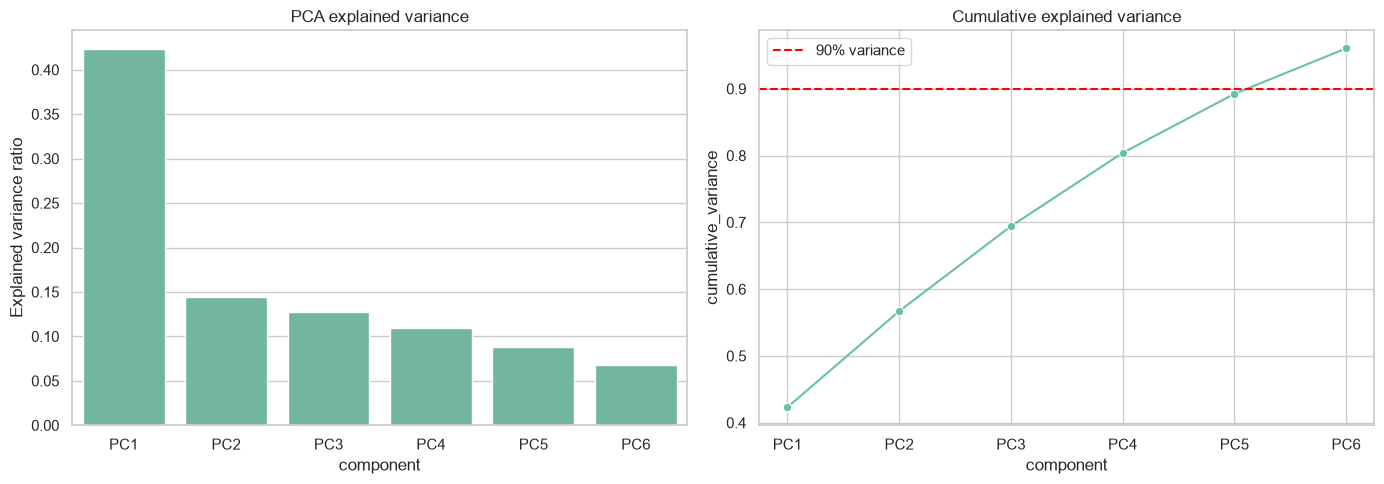

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=pca_variance, x="component", y="explained_variance_ratio", ax=axes[0])
axes[0].set_title("PCA explained variance")
axes[0].set_ylabel("Explained variance ratio")

sns.lineplot(data=pca_variance, x="component", y="cumulative_variance", marker="o", ax=axes[1])
axes[1].axhline(0.90, color="red", linestyle="--", label="90% variance")
axes[1].set_title("Cumulative explained variance")
axes[1].legend()

plt.tight_layout()

## 6. K-Distance Elbow Plot for DBSCAN `eps`

DBSCAN needs two main settings:

- `min_samples`: how many nearby customers are required to form a dense region
- `eps`: the maximum distance for customers to be considered neighbors

This cell builds a k-distance plot. For each customer, it calculates the distance to its `min_samples`-th nearest neighbor, sorts those distances, and plots them.

How to read the graph:

- The flatter part shows customers inside dense areas.
- The sharp upward bend shows where points start becoming farther away.
- The red vertical line marks the suggested elbow area.

The elbow is useful because it gives evidence for a reasonable `eps` value instead of choosing one randomly.


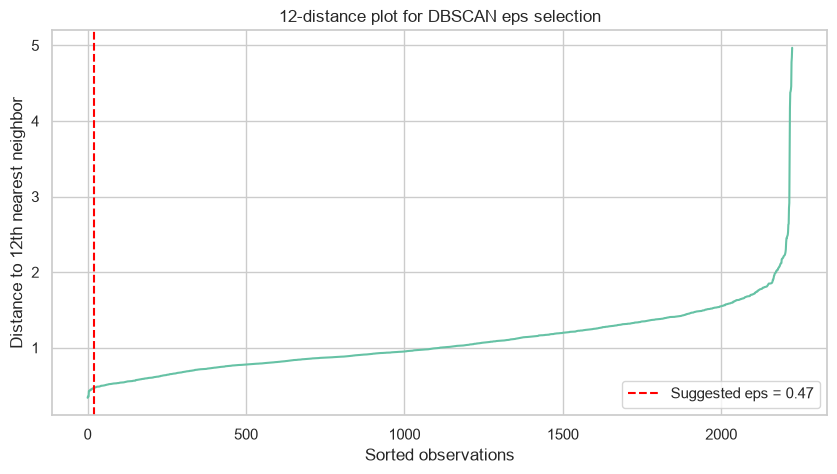

np.float64(0.47236008508330124)

In [6]:
min_samples = max(6, X_pca.shape[1] * 2)
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_pca)
distances, _ = neighbors.kneighbors(X_pca)
k_distances = np.sort(distances[:, -1])

x_norm = np.linspace(0, 1, len(k_distances))
y_norm = (k_distances - k_distances.min()) / (k_distances.max() - k_distances.min())
line = np.linspace(y_norm[0], y_norm[-1], len(y_norm))
elbow_index = np.argmax(y_norm - line)
eps_elbow = k_distances[elbow_index]

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.axvline(elbow_index, color="red", linestyle="--", label=f"Suggested eps = {eps_elbow:.2f}")
plt.title(f"{min_samples}-distance plot for DBSCAN eps selection")
plt.xlabel("Sorted observations")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.legend()
plt.show()

eps_elbow

## 7. DBSCAN Parameter Search

DBSCAN results can change a lot depending on `eps` and `min_samples`, so this cell tests multiple combinations.

For each combination, it records:

- number of clusters found
- number of noise points
- noise rate
- silhouette score
- a combined selection score

The silhouette score measures how separated the clusters are. Higher values usually mean better separation. However, DBSCAN has a weakness in this project: it can get a strong score by creating very small dense clusters and labeling many other customers as noise, or by creating one very large cluster with a few tiny clusters.

Because the professor wants meaningful customer groups, the goal is not just to maximize silhouette. A useful clustering result should also have cluster sizes that make sense for business interpretation.

The displayed table shows the strongest parameter options, and `best_params` shows the selected DBSCAN settings. The next cells show that even after parameter tuning, DBSCAN still does not create well-balanced customer segments for this dataset.


In [7]:
eps_values = sorted(set(np.round(np.r_[
    np.percentile(k_distances, [70, 75, 80, 85, 90, 92, 94, 96, 98]),
    eps_elbow * np.array([0.60, 0.70, 0.80, 0.90, 1.00, 1.10, 1.20]),
], 3)))
min_samples_values = sorted(set([4, 5, 6, 8, 10, min_samples, min_samples + 2]))

dbscan_results = []
for eps in eps_values:
    for sample_count in min_samples_values:
        labels = DBSCAN(eps=eps, min_samples=sample_count).fit_predict(X_pca)
        cluster_labels = [label for label in np.unique(labels) if label != -1]
        n_clusters = len(cluster_labels)
        noise_rate = (labels == -1).mean()

        if n_clusters >= 2 and noise_rate < 0.60:
            non_noise = labels != -1
            score = silhouette_score(X_pca[non_noise], labels[non_noise])
        else:
            score = np.nan

        dbscan_results.append({
            "eps": eps,
            "min_samples": sample_count,
            "n_clusters": n_clusters,
            "noise_rate": noise_rate,
            "silhouette": score,
        })

dbscan_search = pd.DataFrame(dbscan_results)
valid_dbscan = dbscan_search.dropna(subset=["silhouette"]).copy()
valid_dbscan["selection_score"] = valid_dbscan["silhouette"] - valid_dbscan["noise_rate"] * 0.15

multi_cluster_candidates = valid_dbscan[valid_dbscan["n_clusters"] >= 3].copy()
selection_pool = multi_cluster_candidates if not multi_cluster_candidates.empty else valid_dbscan

best_params = selection_pool.sort_values(
    ["selection_score", "n_clusters"],
    ascending=[False, False],
).iloc[0]

display(dbscan_search.sort_values(["silhouette", "noise_rate"], ascending=[False, True]).head(10))
best_params

,eps,min_samples,n_clusters,noise_rate,silhouette
59,1.29,8,2,0.07,0.40
68,1.36,12,2,0.07,0.39
56,1.29,4,2,0.04,0.31
63,1.36,4,2,0.03,0.31
57,1.29,5,2,0.05,0.31
64,1.36,5,2,0.04,0.30
42,0.57,4,66,0.58,0.09
61,1.29,12,2,0.11,0.08
50,1.23,5,4,0.07,0.04
49,1.23,4,5,0.06,0.02


eps               1.23
min_samples       5.00
n_clusters        4.00
noise_rate        0.07
silhouette        0.04
selection_score   0.02
Name: 50, dtype: float64

## 8. Fit the Final DBSCAN Model

This cell runs DBSCAN using the selected `eps` and `min_samples`.

The cluster labels are saved in `DBSCAN_Cluster`:

- `0`, `1`, `2`, etc. are actual customer clusters
- `-1` means DBSCAN considered that customer noise/outlier

The `cluster_counts` table shows how many customers are in each cluster and how many are labeled as noise.

In the current result, the distribution is very uneven:

- cluster `0`: 2039 customers
- cluster `1`: 27 customers
- cluster `2`: 6 customers
- cluster `3`: 5 customers
- noise `-1`: 155 customers

This means DBSCAN mostly found one huge customer group and a few tiny dense pockets. That is not a strong segmentation result, because the smaller clusters are too small to represent practical customer segments.


In [8]:
dbscan = DBSCAN(eps=float(best_params["eps"]), min_samples=int(best_params["min_samples"]))
df["DBSCAN_Cluster"] = dbscan.fit_predict(X_pca)
pca_df["DBSCAN_Cluster"] = df["DBSCAN_Cluster"]

cluster_counts = df["DBSCAN_Cluster"].value_counts().sort_index().rename_axis("cluster").reset_index(name="count")
cluster_counts["cluster_type"] = np.where(cluster_counts["cluster"] == -1, "Noise", "Cluster")
cluster_counts

,cluster,count,cluster_type
0,-1,155,Noise
1,0,2032,Cluster
2,1,27,Cluster
3,2,6,Cluster
4,3,5,Cluster


## 9. DBSCAN Cluster Scatterplot

This graph shows the DBSCAN clusters on the first two PCA components. Because the extreme income outlier was removed before this notebook, the plot is not pulled toward one very distant customer.

Each dot is one customer. The color shows the DBSCAN cluster label.

How to read it:

- Customers with the same color are considered part of the same dense group.
- Points labeled `-1` are noise/outliers.
- If colors appear in separate areas, the clusters are visually different.
- If colors overlap heavily, the clusters may be less clearly separated.

For this dataset, the scatterplot shows the main problem with DBSCAN: most customers are grouped into one dominant cluster, while the other clusters are very small. The graph is useful evidence that DBSCAN was tested, but it does not show a strong density-based segmentation structure.


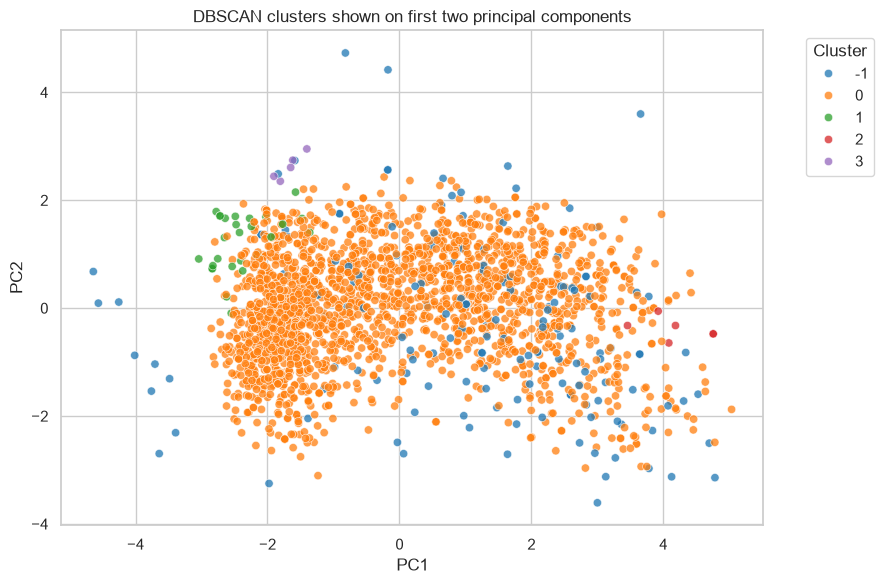

In [9]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="DBSCAN_Cluster",
    palette="tab10",
    alpha=0.75,
)
plt.title("DBSCAN clusters shown on first two principal components")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 10. Cluster Centroids and Profiles

DBSCAN does not naturally create centroids like K-Means does. K-Means is built around cluster centers, but DBSCAN is built around density.

To still describe the center of each DBSCAN cluster, this notebook calculates the **average feature values** for customers inside each non-noise cluster. These averages act as estimated centroids for interpretation.

The `cluster_centroids` table shows the mean values of each selected feature by cluster. These income averages are easier to interpret now because the unrealistic 666k income value is no longer included.

The `cluster_profiles` table gives a more readable customer profile for each cluster using medians and means, including:

- number of customers
- median and mean income
- median age
- median spending
- median purchases
- median recency
- median children

However, the cluster profiles should be interpreted carefully. Since clusters `1`, `2`, and `3` contain very few customers, their averages and medians are not stable enough to describe broad market segments. They are better understood as small dense subgroups or unusual customer pockets, not reliable customer personas.


In [10]:
non_noise = df[df["DBSCAN_Cluster"] != -1].copy()

cluster_centroids = non_noise.groupby("DBSCAN_Cluster")[features].mean()
cluster_profiles = non_noise.groupby("DBSCAN_Cluster").agg(
    customers=("ID", "count"),
    median_income=("Income", "median"),
    mean_income=("Income", "mean"),
    median_age=("Age", "median"),
    median_spending=("Total_Spending", "median"),
    median_purchases=("Total_Purchases", "median"),
    median_recency=("Recency", "median"),
    median_children=("Total_Children", "median"),
)

display(cluster_centroids)
display(cluster_profiles)

,Income,Age,Total_Spending,Total_Purchases,Recency,Total_Children,NumWebVisitsMonth,Total_Campaigns_Accepted
DBSCAN_Cluster,,,,,,,,
0,51030.20,43.88,578.33,14.64,49.08,0.92,5.24,0.34
1,37941.56,49.19,53.00,6.70,45.48,3.00,6.70,0.04
2,84317.67,61.00,1900.50,19.50,60.67,0.00,2.17,3.83
3,51351.10,60.60,63.60,6.80,87.20,3.00,4.80,0.00


,customers,median_income,mean_income,median_age,median_spending,median_purchases,median_recency,median_children
DBSCAN_Cluster,,,,,,,,
0,2032,50616.00,51030.20,43.00,358.00,15.00,49.00,1.00
1,27,35791.00,37941.56,48.00,37.00,6.00,37.00,3.00
2,6,82656.50,84317.67,60.00,2049.00,18.00,62.00,0.00
3,5,51411.00,51351.10,61.00,63.00,7.00,84.00,3.00


## 11. Centroid Heatmap and Cluster Size Chart

This cell creates two final interpretation graphs:

1. **Standardized centroid heatmap**  
   The heatmap compares clusters across features after scaling.  
   - Positive values mean the cluster is above the dataset average for that feature.  
   - Negative values mean the cluster is below the dataset average.  
   - Stronger colors mean bigger differences.

   This makes it easier to describe how each DBSCAN group differs from the average customer.

2. **Cluster size and noise chart**  
   This bar chart shows how many customers belong to each DBSCAN cluster and how many were labeled noise.

   This is the most important graph for judging the DBSCAN result. A useful segmentation should not have almost all customers in one cluster and only a handful in the other clusters.

For this dataset, the size chart shows that DBSCAN did not create balanced or practical customer groups. The heatmap can still describe the tiny clusters, but those tiny groups are too small to be the main segmentation solution.


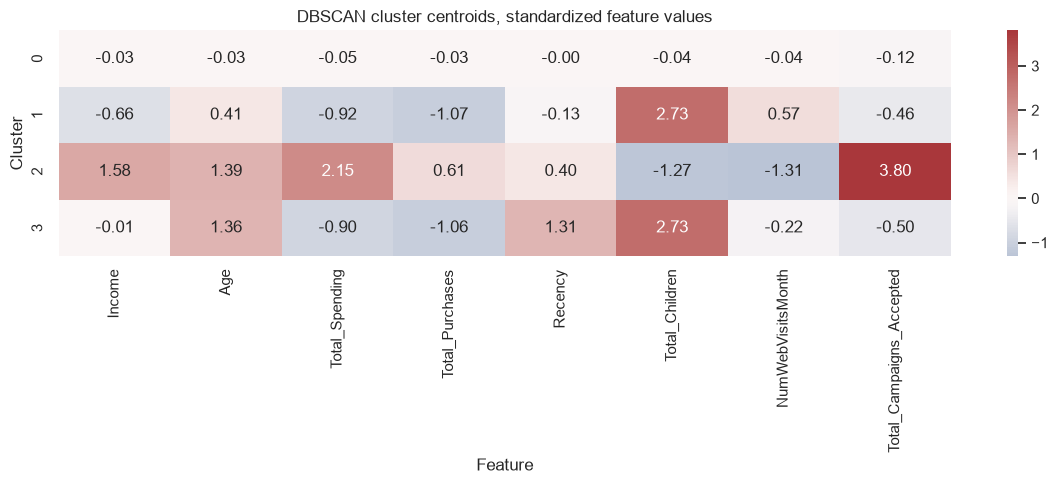

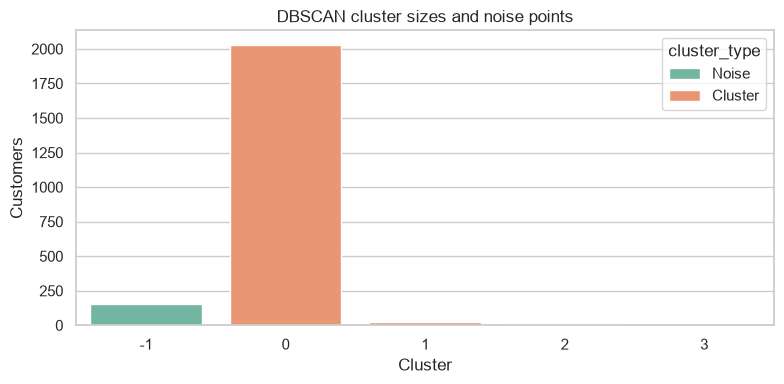

In [11]:
centroid_scaled = pd.DataFrame(
    scaler.transform(cluster_centroids[features]),
    index=cluster_centroids.index,
    columns=features,
)

plt.figure(figsize=(12, 5))
sns.heatmap(centroid_scaled, annot=True, cmap="vlag", center=0, fmt=".2f")
plt.title("DBSCAN cluster centroids, standardized feature values")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=cluster_counts, x="cluster", y="count", hue="cluster_type", dodge=False)
plt.title("DBSCAN cluster sizes and noise points")
plt.xlabel("Cluster")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

## Overall DBSCAN Interpretation

DBSCAN was included because the professor asked us to compare multiple clustering methods, including a density-based method. The method was applied correctly: the data was scaled, PCA was used to reduce noise, a k-distance elbow plot was used to guide `eps`, and a parameter search tested different DBSCAN settings.

However, the result shows that DBSCAN is **not the best clustering method for this dataset**.

The main evidence is the cluster size distribution:

- one cluster contains 2039 customers
- the remaining clusters contain only 27, 6, and 5 customers
- 155 customers are labeled as noise

This means DBSCAN did not find several meaningful dense customer groups. Instead, it found one large general group and a few tiny dense pockets. Those tiny groups may be interesting as outliers or niche subgroups, but they are not strong enough to use as the main customer segmentation.

This likely happens because the customer data is made of continuous demographic and spending variables. The customers do not appear to form clearly separated dense regions in the feature space. DBSCAN works best when groups have clear density separation, but this dataset seems better suited for methods that partition broader patterns, such as K-Means or Hierarchical Clustering.

Final conclusion:

DBSCAN was useful as a comparison method, but its output is not practical for the final segmentation. The project should explain that density-based clustering was tested and rejected because it produced one dominant cluster, several tiny clusters, and noise rather than balanced, interpretable customer segments. A refined K-Means or Hierarchical approach is likely more appropriate for the final customer personality analysis.
